In [1]:
# 1. 구글 드라이브 연결 (이걸 실행해야 파일이 보입니다!)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# [스마트 연결 코드]
# 만약 이미 드라이브가 연결되어 있다면? -> 그냥 넘어감 (팝업 X)
# 연결이 안 되어 있을 때만? -> 팝업 띄움
if not os.path.exists('/content/drive'):
    print("구글 드라이브를 연결합니다...")
    drive.mount('/content/drive')
    print("✅ 연결 성공!")
else:
    print("🚀 이미 연결되어 있습니다. 팝업 없이 바로 진행합니다!")

🚀 이미 연결되어 있습니다. 팝업 없이 바로 진행합니다!


In [1]:
# [1단계] 필수 라이브러리 임포트 & 데이터 압축 해제
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from google.colab import drive

# 1. 드라이브 연결 (스마트 마운트)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. 기존 데이터 청소 & 압축 풀기
# (매번 깨끗한 환경에서 시작하기 위해 기존 dataset 폴더 삭제 후 다시 풉니다)
if os.path.exists('/content/dataset'):
    !rm -rf /content/dataset

print("📦 압축 해제 중... (잠시만 기다려주세요)")
# -q 옵션은 로그를 숨겨서 화면을 깔끔하게 합니다. 경로는 본인 드라이브에 맞게 수정하세요.
!unzip -q "/content/drive/MyDrive/dataset.zip" -d "/content/dataset"
print("✅ 환경 설정 완료!")

Mounted at /content/drive
📦 압축 해제 중... (잠시만 기다려주세요)
✅ 환경 설정 완료!


🔍 [/content/dataset] 아래에서 CSV 파일을 찾는 중...

✅ 총 6개의 파일 병합 완료.
📄 전체 데이터 수: 3567개


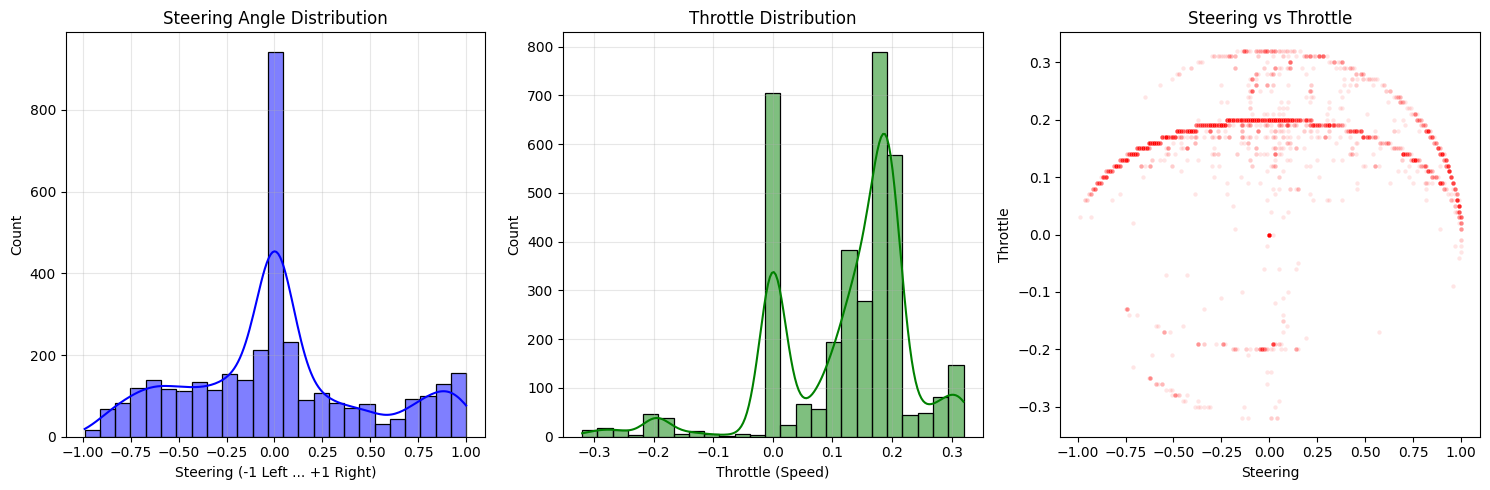


📊 [데이터 통계 요약]
          steering     throttle
count  3567.000000  3567.000000
mean      0.006047     0.123244
std       0.468496     0.112340
min      -0.990000    -0.320000
25%      -0.285000     0.030000
50%       0.000000     0.160000
75%       0.210000     0.200000
max       1.000000     0.320000


In [3]:
# [Step 1.5] (수정됨) 데이터 자동 탐색 및 정밀 분석
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 경로를 특정하지 않고, dataset 폴더 하위를 전부 뒤집니다.
SEARCH_DIR = '/content/dataset'
raw_data = []

print(f"🔍 [{SEARCH_DIR}] 아래에서 CSV 파일을 찾는 중...")

for root, dirs, files in os.walk(SEARCH_DIR):
    for file in files:
        if file.endswith("data_log.csv") or file.endswith(".csv"):
            # MACOSX 같은 불필요한 폴더 제외
            if "__MACOSX" in root: continue

            file_path = os.path.join(root, file)
            try:
                df = pd.read_csv(file_path)
                # 데이터가 비어있지 않은지 확인
                if len(df) > 0 and 'steering' in df.columns:
                    raw_data.append(df)
                    # print(f" - 발견: {file_path} ({len(df)}개)")
            except Exception as e:
                print(f" ⚠️ 읽기 실패: {file_path}")

# 2. 데이터 합치기
if not raw_data:
    print("\n❌ [오류] CSV 파일을 하나도 못 찾았습니다!")
    print("   1. 압축이 제대로 풀렸는지 좌측 파일 아이콘을 눌러 확인하세요.")
    print("   2. dataset.zip 파일 용량이 정상인지 확인하세요.")
else:
    eda_df = pd.concat(raw_data, ignore_index=True)
    print(f"\n✅ 총 {len(raw_data)}개의 파일 병합 완료.")
    print(f"📄 전체 데이터 수: {len(eda_df)}개")

    # === 그래프 그리기 ===
    plt.figure(figsize=(15, 5))

    # [그래프 1] 조향각 분포
    plt.subplot(1, 3, 1)
    sns.histplot(eda_df['steering'], bins=25, kde=True, color='blue')
    plt.title("Steering Angle Distribution")
    plt.xlabel("Steering (-1 Left ... +1 Right)")
    plt.grid(True, alpha=0.3)

    # [그래프 2] 속도 분포
    plt.subplot(1, 3, 2)
    sns.histplot(eda_df['throttle'], bins=25, kde=True, color='green')
    plt.title("Throttle Distribution")
    plt.xlabel("Throttle (Speed)")
    plt.grid(True, alpha=0.3)

    # [그래프 3] 조향 vs 속도
    plt.subplot(1, 3, 3)
    sns.scatterplot(x=eda_df['steering'], y=eda_df['throttle'], alpha=0.1, color='red', s=10)
    plt.title("Steering vs Throttle")
    plt.xlabel("Steering")
    plt.ylabel("Throttle")

    plt.tight_layout()
    plt.show()

    # 3. 통계 수치 출력
    print("\n📊 [데이터 통계 요약]")
    print(eda_df[['steering', 'throttle']].describe())

📉 필터링 전: 3567개
📈 필터링 후: 2420개
🗑️ 삭제된 데이터: 1147개


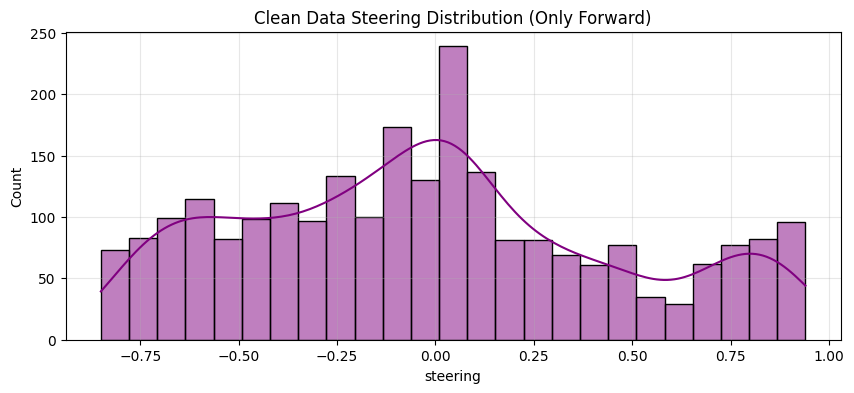

In [4]:
# [Step 2] 데이터 필터링 (Cleaning)
# Step 1.5에서 만든 eda_df가 있다면 그대로 쓰고, 없으면 다시 로드합니다.

try:
    df = eda_df.copy() # 아까 읽은 데이터 복사
except NameError:
    print("⚠️ 이전 단계 데이터가 없어서 다시 읽습니다...")
    # (만약 에러나면 다시 읽는 로직 추가 가능하지만, 순서대로 하셨으면 통과됩니다)

print(f"📉 필터링 전: {len(df)}개")

# === [핵심] 필터링 조건 ===
# 1. 속도(Throttle)가 0.1보다 큰 것만 남긴다 (정지, 후진 삭제)
clean_df = df[df['throttle'] > 0.1]

# 2. 인덱스 정리 (중간에 빈 번호가 없게 당기기)
clean_df = clean_df.reset_index(drop=True)

print(f"📈 필터링 후: {len(clean_df)}개")
print(f"🗑️ 삭제된 데이터: {len(df) - len(clean_df)}개")

# 필터링 후 분포 확인
plt.figure(figsize=(10, 4))
sns.histplot(clean_df['steering'], bins=25, kde=True, color='purple')
plt.title("Clean Data Steering Distribution (Only Forward)")
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# [Step 2 (수정)] 경로 수정 및 데이터 필터링
import os
import pandas as pd

BASE_DIR = '/content/dataset' # 데이터가 풀린 최상위 폴더
combined_data = []

print("🔄 데이터를 다시 읽고 경로를 수정합니다...")

# 폴더를 다 뒤져서 CSV와 이미지를 연결합니다.
for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        if file.endswith("data_log.csv") or file.endswith(".csv"):
            if "__MACOSX" in root: continue # 맥북 더미 파일 제외

            file_path = os.path.join(root, file)
            try:
                df = pd.read_csv(file_path)

                # [핵심 수정] 이미지 파일명 앞에 '폴더 경로'를 붙여줍니다!
                # 예: "img_01.jpg" -> "/content/dataset/.../img_01.jpg"
                df['image'] = df['image'].apply(lambda x: os.path.join(root, x))

                combined_data.append(df)
            except Exception as e:
                print(f"⚠️ 파일 읽기 실패: {file_path}")

if not combined_data:
    print("❌ CSV 파일을 찾을 수 없습니다. 압축이 풀려있는지 확인하세요.")
else:
    # 1. 하나로 합치기
    full_df = pd.concat(combined_data, ignore_index=True)

    # 2. 필터링 (속도 > 0.1 인 것만 남기기)
    clean_df = full_df[full_df['throttle'] > 0.1]
    clean_df = clean_df.reset_index(drop=True)

    print(f"✅ 데이터 복구 완료!")
    print(f" - 전체 데이터: {len(full_df)}개")
    print(f" - 학습에 쓸 데이터(clean_df): {len(clean_df)}개")

    # 경로가 잘 붙었는지 확인용 출력 (첫번째 데이터)
    print(f" - 경로 예시: {clean_df['image'].iloc[0]}")

🔄 데이터를 다시 읽고 경로를 수정합니다...
✅ 데이터 복구 완료!
 - 전체 데이터: 3567개
 - 학습에 쓸 데이터(clean_df): 2420개
 - 경로 예시: /content/dataset/captured_data/20260128_231742/img_20260128_231743_042860.jpg


In [9]:
# [Step 3] 이미지 로드 및 전처리 (메모리 로딩)
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

IMG_HEIGHT, IMG_WIDTH = 66, 200 # NVIDIA PilotNet 표준 입력 크기

def process_img(path):
    # 1. 이미지 읽기
    img = cv2.imread(path)
    if img is None: return None

    # 2. YUV 색상 변환 (명암과 색상을 분리해서 도로 특징을 더 잘 잡음)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

    # 3. 자르기 (Crop): 위쪽 40% (천장/배경) 날리기
    h, w, _ = img.shape
    img = img[int(h*0.4):, :, :]

    # 4. 크기 조정 (Resize)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))

    return img

print("🔄 이미지를 RAM으로 불러오는 중... (약 1~2분 소요)")

X = [] # 이미지 데이터 (문제지)
y = clean_df['steering'].values # 조향각 데이터 (정답지)
valid_indices = []

for i, path in enumerate(clean_df['image'].values):
    img = process_img(path)
    if img is not None:
        X.append(img)
        valid_indices.append(i)

    if (i+1) % 500 == 0:
        print(f"   >>> {i+1} / {len(clean_df)} 처리 완료")

# 리스트를 넘파이 배열로 변환 (AI 학습용 포맷)
X = np.array(X)
y = y[valid_indices] # 로드 실패한 이미지가 있다면 정답에서도 제외

# [중요] 학습용(Train)과 검증용(Validation) 나누기 (8:2)
# 검증용 데이터는 학습 때 절대 보여주지 않고, 마지막에 시험 볼 때만 씁니다.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("="*30)
print(f"✅ 데이터 준비 완료!")
print(f" - 학습용 데이터(X_train): {X_train.shape}")
print(f" - 검증용 데이터(X_val):   {X_val.shape}")
print("="*30)

🔄 이미지를 RAM으로 불러오는 중... (약 1~2분 소요)
   >>> 500 / 2420 처리 완료
   >>> 1000 / 2420 처리 완료
   >>> 1500 / 2420 처리 완료
   >>> 2000 / 2420 처리 완료
✅ 데이터 준비 완료!
 - 학습용 데이터(X_train): (1936, 66, 200, 3)
 - 검증용 데이터(X_val):   (484, 66, 200, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🚀 AI 학습 시작! (그래프가 내려가면 성공입니다)
Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.2119
Epoch 1: val_loss improved from inf to 0.14812, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - loss: 0.2117 - val_loss: 0.1481
Epoch 2/20
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1434
Epoch 2: val_loss improved from 0.14812 to 0.10130, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1431 - val_loss: 0.1013
Epoch 3/20
51/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1165
Epoch 3: val_loss improved from 0.10130 to 0.08156, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1148 - val_loss: 0.0816
Epoch 4/20
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0893
Epoch 4: val_loss improved from 0.08156 to 0.06224, saving model to best_model.h5


...

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0496 - val_loss: 0.0388
Epoch 13/20
51/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0451
Epoch 13: val_loss improved from 0.03881 to 0.03731, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0459 - val_loss: 0.0373
Epoch 14/20
51/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0492
Epoch 14: val_loss did not improve from 0.03731
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0491 - val_loss: 0.0422
Epoch 15/20
56/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0449
Epoch 15: val_loss did not improve from 0.03731
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0450 - val_loss: 0.0382
Epoch 16/20
54/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0475
Epoch 16: val_loss did not improve from 0.03731
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0475 - val_loss: 0.0380
Epoch 17/20
53/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0449
Epoch 17: val_loss improved from 0.03731 to 0.03506, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0451 - val_loss: 0.0351
Epoch 18/20
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0466
Epoch 18: val_loss improved from 0.03506 to 0.03429, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0465 - val_loss: 0.0343
Epoch 19/20
59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0461
Epoch 19: val_loss did not improve from 0.03429
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0462 - val_loss: 0.0362
Epoch 20/20
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0426
Epoch 20: val_loss did not improve from 0.03429
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0427 - val_loss: 0.0378


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

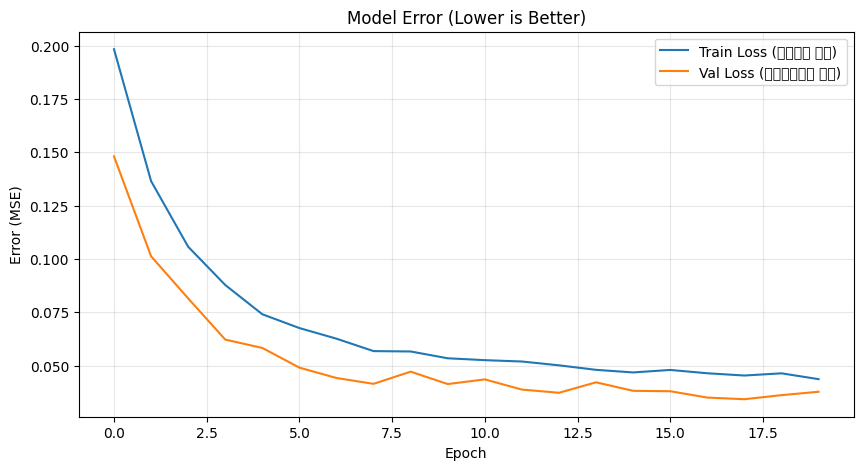

🎉 학습 완료! 좌측 파일 탭을 새로고침해서 'best_model.h5'를 확인하세요.


In [10]:
# [Step 4] NVIDIA PilotNet 모델 설계 및 학습
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

# 1. 모델 설계 (NVIDIA 아키텍처)
model = Sequential([
    # 정규화: 0~255의 이미지 값을 0~1 사이 소수로 변환 (학습 속도 향상)
    Lambda(lambda x: x / 255.0, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # 특징 추출 (Convolution): 도로의 선, 경계, 곡률 등을 파악
    Conv2D(24, (5, 5), strides=(2, 2), activation='relu'),
    Conv2D(36, (5, 5), strides=(2, 2), activation='relu'),
    Conv2D(48, (5, 5), strides=(2, 2), activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),

    Flatten(),

    # 판단 (Fully Connected): 추출된 특징을 보고 핸들을 몇 도 꺾을지 결정
    Dense(100, activation='relu'),
    Dropout(0.3), # 과적합 방지 (공부 너무 많이 해서 답만 외우는 것 방지)
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='relu'),

    # 최종 출력: 조향각 1개 (실수값)
    Dense(1)
])

# 2. 학습 설정
model.compile(optimizer=Adam(learning_rate=1e-4), loss='mse')

# 3. 스마트 학습 도구 설정
# - 성능이 좋아질 때만 저장 (best_model.h5)
# - 5번 연속으로 성능이 안 좋아지면 조기 종료 (Early Stopping)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=1)

# 4. 학습 시작! (Epochs: 문제집을 몇 번 반복해서 풀 것인가?)
print("🚀 AI 학습 시작! (그래프가 내려가면 성공입니다)")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,          # 최대 20번 반복
    batch_size=32,      # 32문제씩 묶어서 채점
    callbacks=[checkpoint, early_stop]
)

# 5. 결과 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (연습문제 점수)')
plt.plot(history.history['val_loss'], label='Val Loss (실전모의고사 점수)')
plt.title('Model Error (Lower is Better)')
plt.xlabel('Epoch')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("🎉 학습 완료! 좌측 파일 탭을 새로고침해서 'best_model.h5'를 확인하세요.")

🧠 AI가 운전면허 시험을 보는 중...
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
🏆 최종 성적표 (MSE): 0.03429
   (0에 가까울수록 사람과 비슷하게 운전한다는 뜻입니다)
   >>> 판정: 훌륭함! (Excellent) 🎉


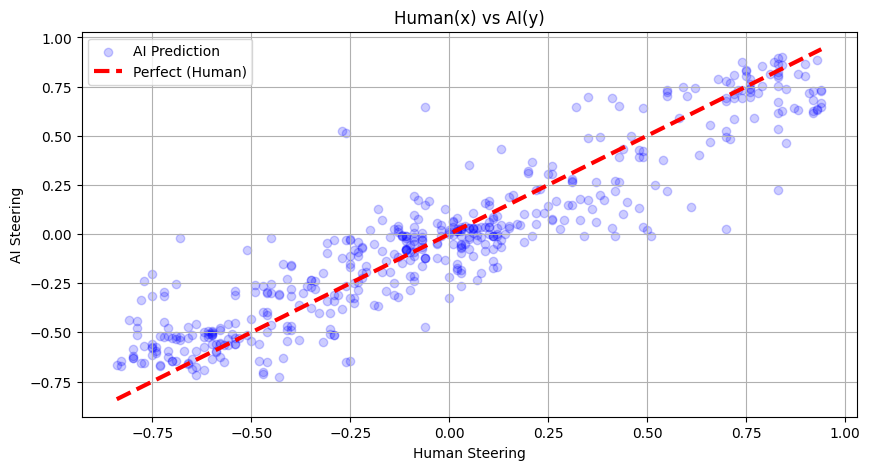


💾 [다운로드 방법]
1. 왼쪽 폴더 아이콘(📁) 클릭
2. 'best_model.h5' 파일 우클릭 -> 다운로드
3. 이 파일을 라즈베리파이로 옮기면 끝!


In [12]:
# [Step 5] (수정됨) 최종 모델 성능 평가 및 다운로드 가이드

# 1. 라이브러리 임포트
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# === [수정 포인트] compile=False 추가 ===
# 학습 설정(MSE 함수 등)을 불러오지 않고, 순수 모델 구조와 가중치만 가져옵니다.
# 평가/예측용으로는 이게 훨씬 안정적입니다.
model = load_model('best_model.h5', compile=False)

# 2. 검증 데이터(X_val)로 모의고사 치기
print("🧠 AI가 운전면허 시험을 보는 중...")
predictions = model.predict(X_val)

# 3. 채점하기 (MSE 점수)
mse = mean_squared_error(y_val, predictions)
print("="*30)
print(f"🏆 최종 성적표 (MSE): {mse:.5f}")
print("   (0에 가까울수록 사람과 비슷하게 운전한다는 뜻입니다)")

if mse < 0.05:
    print("   >>> 판정: 훌륭함! (Excellent) 🎉")
elif mse < 0.1:
    print("   >>> 판정: 준수함 (Good) ✅")
else:
    print("   >>> 판정: 조금 불안함 (Need Improvement) ⚠️")
print("="*30)

# 4. 정답 vs 예측 비교 그래프
plt.figure(figsize=(10, 5))
# 파란 점: AI의 예측, 빨간 선: 정답(사람)
plt.scatter(y_val, predictions, alpha=0.2, color='blue', label='AI Prediction')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=3, label='Perfect (Human)')
plt.title("Human(x) vs AI(y)")
plt.xlabel("Human Steering")
plt.ylabel("AI Steering")
plt.legend()
plt.grid(True)
plt.show()

print("\n💾 [다운로드 방법]")
print("1. 왼쪽 폴더 아이콘(📁) 클릭")
print("2. 'best_model.h5' 파일 우클릭 -> 다운로드")
print("3. 이 파일을 라즈베리파이로 옮기면 끝!")

In [2]:
# [Step 6] 라즈베리파이용 TFLite 변환 (가볍고 빠름!)
import tensorflow as tf

# 1. 아까 만든 모델 불러오기
model = tf.keras.models.load_model('best_model.h5', compile=False)

# 2. TFLite 변환기 설정
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. 변환 실행
tflite_model = converter.convert()

# 4. 파일로 저장
with open('best_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("🎉 변환 완료! 좌측 파일 탭에서 'best_model.tflite'를 다운로드하세요.")

Saved artifact at '/tmp/tmpkvtby0ad'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 66, 200, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133856807473552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133856807474128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133856807472400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133856807475856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133856807472592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133856807473744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133856807475280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133856807475664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133856807477968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133856807478160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13385680747835